# (노트) First CNN
> 완성 (env:2021bda)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [파이토치]

### ref

`-` https://ipywidgets.readthedocs.io/en/stable/user_install.html

### check jupyter version

In [1]:
! jupyter --version

jupyter core     : 4.7.1
jupyter-notebook : 6.4.3
qtconsole        : 5.1.1
ipython          : 7.26.0
ipykernel        : 6.2.0
jupyter client   : 6.1.12
jupyter lab      : 3.1.8
nbconvert        : 5.6.1
ipywidgets       : 7.6.3
nbformat         : 5.1.3
traitlets        : 5.0.5


주피터랩 버전이 3.0>0 이상임

### install pkgs

In [2]:
#!pip install fastai
#!pip install graphviz
#!conda install -c conda-forge jupyterlab_widgets -y
#!conda install -c conda-forge ipywidgets -y
#!conda install -c conda-forge nodejs -y

### import 

In [3]:
from fastai.vision.all import *
from fastai.vision.widgets import *

### download data (cat and dog images)

In [4]:
path=untar_data(URLs.PETS)/'images'

In [5]:
path

Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images')

In [20]:
path.ls()

(#7395) [Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_224.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/miniature_pinscher_58.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_bulldog_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Persian_85.jpg')...]

> - `URLs.PETS`는 그냥 https://s3.amazonaws.com/fast-ai-imageclas/oxford-iiit-pet.tgz 가 저장된 스트링.. 
> - untar_data()는 fastai에서 제공하는 함수. URL주소를 str으로 받으면 PosixPath Type의 인스턴스를 반환한다. 
> - PosixPath는 파이썬 자체에서 제공되는 자료형인듯. (이런건 [공식문서](https://docs.python.org/ko/3/library/pathlib.html)가 잘 정리되어있다.) 
> - PosixPath 타입은 `/` operator를 통해 문자열과 결합할 수 있음. 
> - PosixPath 타입은 ls method를 통하여 path에 저장된 파일들의 목록을 출력할 수 있음

In [7]:
files = get_image_files(path)
files

(#7390) [Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_224.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/miniature_pinscher_58.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_bulldog_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Persian_85.jpg')...]

In [8]:
files[0],files[1],files[2],files[3],files[4]

(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),
 Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'),
 Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'),
 Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'),
 Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'))

In [9]:
def label_func(f): 
    if f[0].isupper(): 
        return 'cat'
    else: 
        return 'dog'

In [10]:
label_func('asdf')

'dog'

In [11]:
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224)) ## 데이터로더는 좀더 탐구필요
# dls = ImageDataLoaders.from_name_func(
#     path, get_image_files(path),valid_pct=0.2, seed=42, 
#     label_func=is_cat, item_tfms=Resize(224))

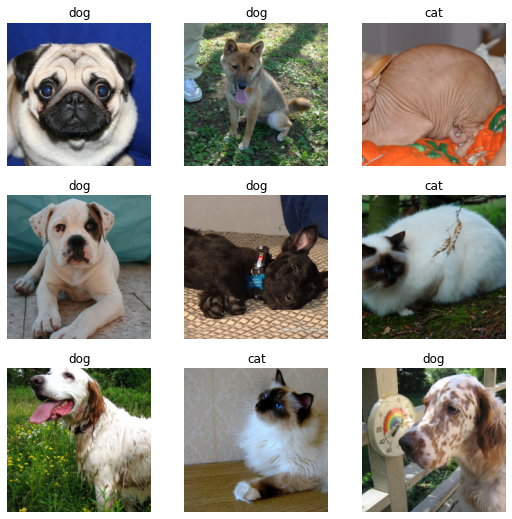

In [12]:
dls.show_batch(max_n=9) # 실행할때마다 결과바뀜 

### my first model

In [13]:
learn=cnn_learner(dls,resnet34, metrics=error_rate)

/home/cgb4/anaconda3/envs/2021bda/lib/python3.8/site-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /tmp/pip-req-build-pma2oi4d/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


In [14]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.120118,0.026005,0.006766,00:11


epoch,train_loss,valid_loss,error_rate,time
0,0.054232,0.020509,0.008119,00:11


>  CPU vs GPU 하면 좋을듯

In [15]:
learn.predict(files[0])

('dog', tensor(1), tensor([7.4642e-07, 1.0000e+00]))

> Note: 그림파일이 저장된 경로를 PosixPath타입으로 전달하면 예측결과가 출력됨 

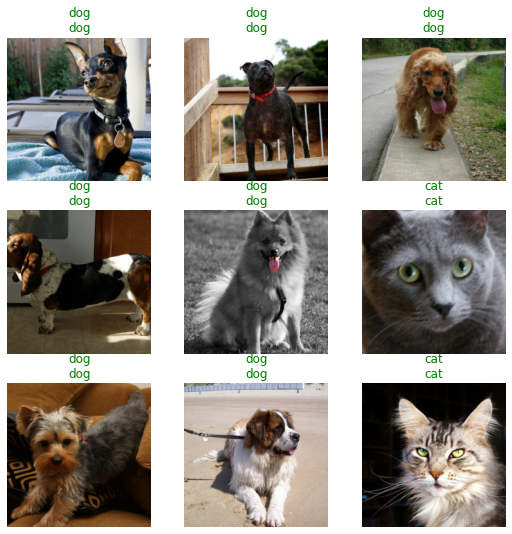

In [16]:
learn.show_results()

### 오답분석 

In [17]:
interp = Interpretation.from_learner(learn)

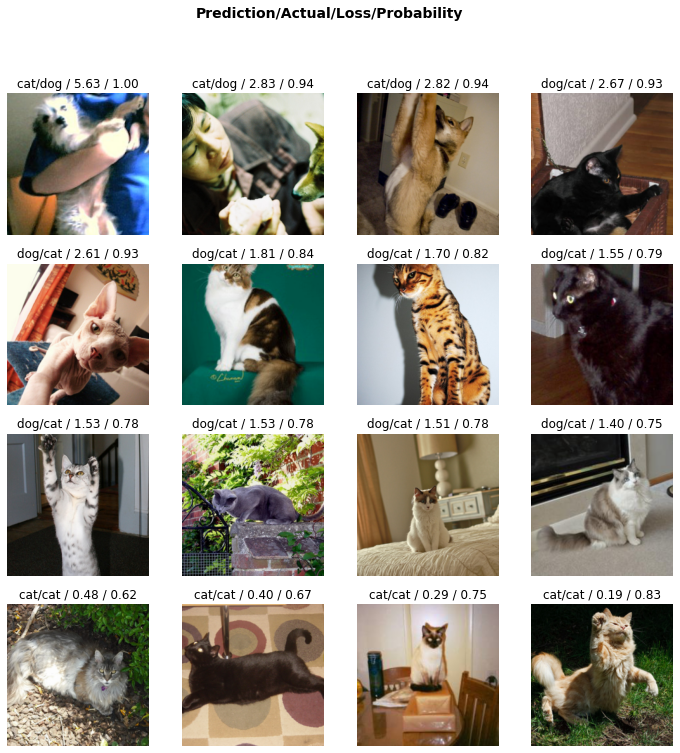

In [19]:
interp.plot_top_losses(16)

### Deploy

In [21]:
#import ipywidgets as widgets
uploader=widgets.FileUpload()
display(uploader)

FileUpload(value={}, description='Upload')

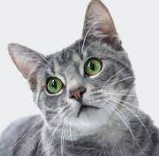

In [22]:
img=PILImage.create(uploader.data[0])
img

In [25]:
pred,_,probs = learn.predict(img)

In [27]:
pred,probs

('cat', tensor([1.0000e+00, 9.0569e-17]))

### test with image crolling 

`-` https://github.com/fastai/fastbook/blob/master/utils.py 에서 search_images_ddf() 함수를 참고

In [28]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return L(set(urls))     # dedupe
            if 'next' not in data: return L(set(urls))
            requestUrl = url + data['next']
        except:
            pass


In [30]:
urls = search_images_ddg('강아지', max_n=10)
len(urls),urls[0]

(10, 'http://cfile30.uf.tistory.com/image/2154C03A57D6C4CA31D1AD')

In [31]:
learn.predict(urls[0])

FileNotFoundError: [Errno 2] No such file or directory: 'http://cfile30.uf.tistory.com/image/2154C03A57D6C4CA31D1AD'

In [19]:
def download_url(url, dest, overwrite=False, pbar=None, show_progress=True, chunk_size=1024*1024,
                 timeout=4, retries=5):
    "Download `url` to `dest` unless it exists and not `overwrite`"
    if os.path.exists(dest) and not overwrite: return

    s = requests.Session()
    s.mount('http://',requests.adapters.HTTPAdapter(max_retries=retries))
    # additional line to identify as a firefox browser, see fastai/#2438
    s.headers.update({'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'})
    u = s.get(url, stream=True, timeout=timeout)
    try: file_size = int(u.headers["Content-Length"])
    except: show_progress = False

    with open(dest, 'wb') as f:
        nbytes = 0
        if show_progress: pbar = progress_bar(range(file_size), leave=False, parent=pbar)
        try:
            if show_progress: pbar.update(0)
            for chunk in u.iter_content(chunk_size=chunk_size):
                nbytes += len(chunk)
                if show_progress: pbar.update(nbytes)
                f.write(chunk)
        except requests.exceptions.ConnectionError as e:
            fname = url.split('/')[-1]
            data_dir = dest.parent
            print(f'\n Download of {url} has failed after {retries} retries\n'
                  f' Fix the download manually:\n'
                  f'$ mkdir -p {data_dir}\n'
                  f'$ cd {data_dir}\n'
                  f'$ wget -c {url}\n'
                  f'$ tar xf {fname}\n'
                  f' And re-run your code once the download is successful\n')


`-` ref: https://github.com/fastai/fastai2/blob/master/fastai2/data/external.py

In [53]:
imgs=[]
for i in range(len(urls)):
    download_url(urls[i],'temp.jpg')
    imgs=imgs+[Image.open('temp.jpg')]
    imgs[i].thumbnail((256,256))

In [62]:
a=Image.open('temp.jpg')

In [74]:
imgs

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056AF0>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056820>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056730>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056AC0>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056C10>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056790>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35795B6A00>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE056FA0>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE071130>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=192x256 at 0x7F35EE071070>]

In [144]:
uploader=widgets.FileUpload()
display(uploader)

FileUpload(value={}, description='Upload')

In [145]:
img=PILImage.create(uploader.data[0])
is_cat,_,probs = learn.predict(img)

IndexError: list index out of range

In [146]:
is_cat

'False'

In [147]:
probs

tensor([9.9991e-01, 8.9673e-05])

### publish

In [167]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

In [168]:
#img=PILImage.create(btn_upload.data[-1])

In [169]:
out_pl=widgets.Output()
# out_pl.clear_output()
# with out_pl: display(img.to_thumb(128,128))
# out_pl

In [170]:
#pred,pred_idx,probs=learn.predict(img)

In [171]:
lbl_pred=widgets.Label()

In [172]:
#lbl_pred.value=f'Prediction:{pred}; Probability:{probs[pred_idx]:}'

In [173]:
lbl_pred

Label(value='')

In [174]:
btn_run=widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [178]:
def on_click_classify(change):
    img=PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs=learn.predict(img)
    lbl_pred.value=f'Prediction:{pred};Probability:{probs[pred_idx]:}'
btn_run.on_click(on_click_classify)    

In [179]:
VBox([widgets.Label('Select your bear!'),
      btn_upload, btn_run, out_pl, lbl_pred])